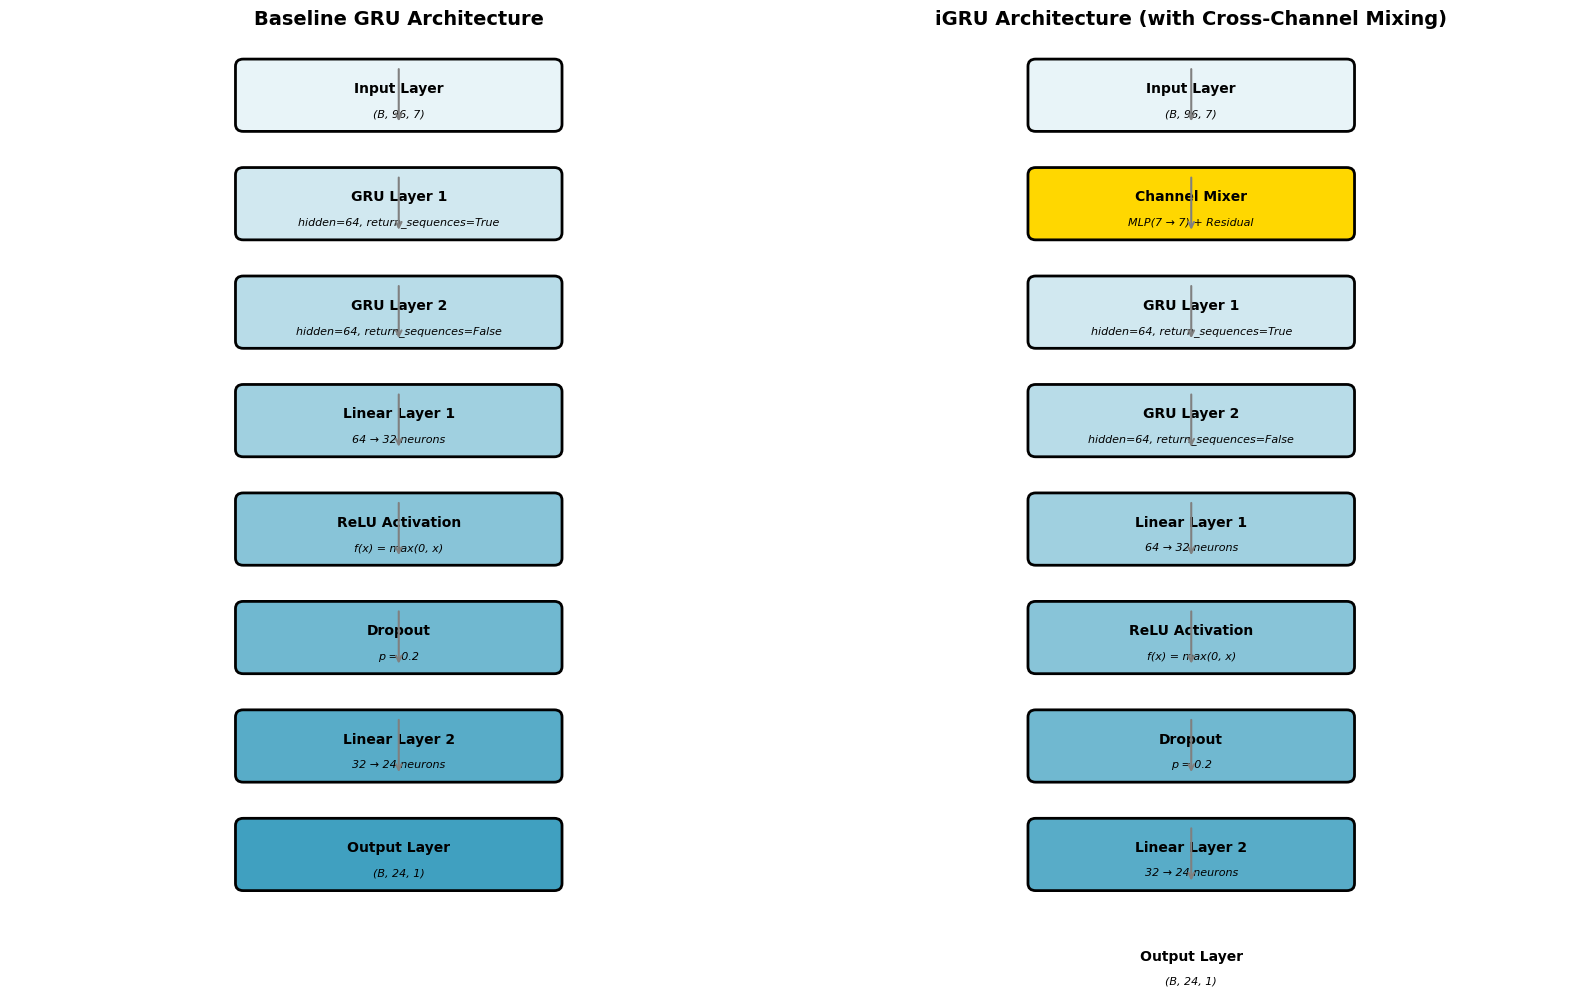

✅ Architecture diagram saved to 'architecture_diagram.png'


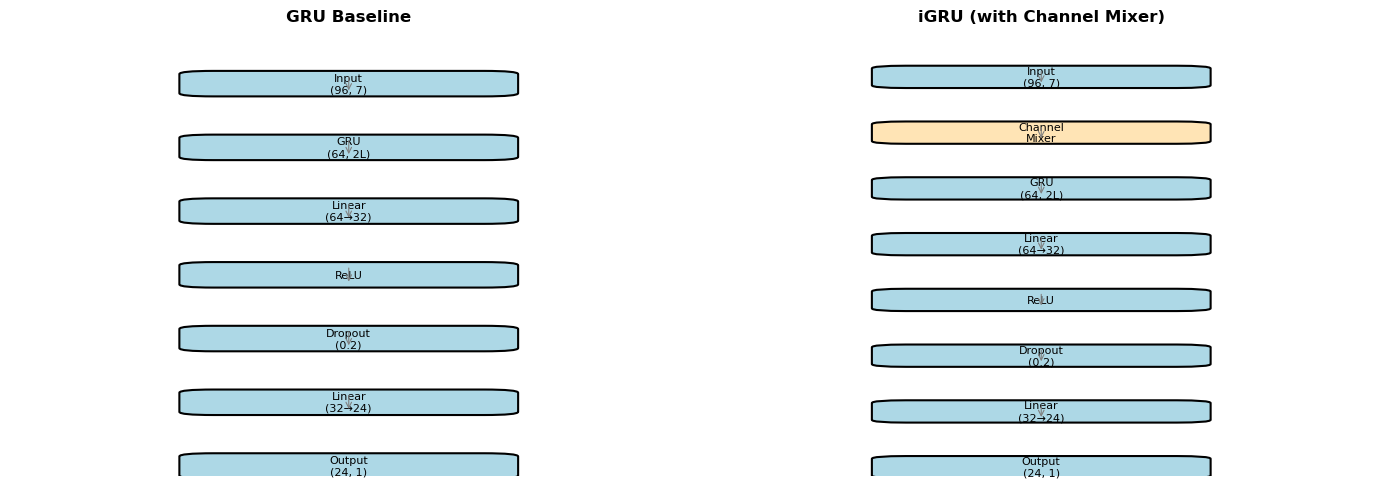

✅ Simplified architecture diagram saved to 'simplified_architecture.png'


In [5]:
"""
Generate Professional Architecture Diagrams for Report
Run this in a Jupyter cell or Python script
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

def draw_architecture_diagram():
    """Draw professional GRU architecture diagram"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
    
    # ============================================================
    # BASELINE GRU ARCHITECTURE
    # ============================================================
    
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 12)
    ax1.set_title('Baseline GRU Architecture', fontsize=14, fontweight='bold', pad=20)
    ax1.axis('off')
    
    # Define box positions (x, y, width, height)
    layers = [
        {'name': 'Input Layer', 'shape': '(B, 96, 7)', 'y': 11, 'color': '#E8F4F8'},
        {'name': 'GRU Layer 1', 'shape': 'hidden=64, return_sequences=True', 'y': 9.5, 'color': '#D1E8F0'},
        {'name': 'GRU Layer 2', 'shape': 'hidden=64, return_sequences=False', 'y': 8, 'color': '#B8DCE8'},
        {'name': 'Linear Layer 1', 'shape': '64 → 32 neurons', 'y': 6.5, 'color': '#A0D0E0'},
        {'name': 'ReLU Activation', 'shape': 'f(x) = max(0, x)', 'y': 5, 'color': '#88C4D8'},
        {'name': 'Dropout', 'shape': 'p = 0.2', 'y': 3.5, 'color': '#70B8D0'},
        {'name': 'Linear Layer 2', 'shape': '32 → 24 neurons', 'y': 2, 'color': '#58ACC8'},
        {'name': 'Output Layer', 'shape': '(B, 24, 1)', 'y': 0.5, 'color': '#40A0C0'}
    ]
    
    for layer in layers:
        # Draw box
        box = FancyBboxPatch((3, layer['y']), 4, 0.8, 
                              boxstyle="round,pad=0.1",
                              facecolor=layer['color'], 
                              edgecolor='black', 
                              linewidth=2)
        ax1.add_patch(box)
        
        # Add text
        ax1.text(5, layer['y'] + 0.5, layer['name'], 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax1.text(5, layer['y'] + 0.15, layer['shape'], 
                ha='center', va='center', fontsize=8, style='italic')
        
        # Draw arrow
        if layer['y'] > 0.5:
            ax1.annotate('', xy=(5, layer['y']), xytext=(5, layer['y'] + 0.8),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    
    # ============================================================
    # iGRU ARCHITECTURE (with Channel Mixer)
    # ============================================================
    
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 12)
    ax2.set_title('iGRU Architecture (with Cross-Channel Mixing)', fontsize=14, fontweight='bold', pad=20)
    ax2.axis('off')
    
    iGRU_layers = [
        {'name': 'Input Layer', 'shape': '(B, 96, 7)', 'y': 11, 'color': '#E8F4F8'},
        {'name': 'Channel Mixer', 'shape': 'MLP(7 → 7) + Residual', 'y': 9.5, 'color': '#FFE4B5'},
        {'name': 'GRU Layer 1', 'shape': 'hidden=64, return_sequences=True', 'y': 8, 'color': '#D1E8F0'},
        {'name': 'GRU Layer 2', 'shape': 'hidden=64, return_sequences=False', 'y': 6.5, 'color': '#B8DCE8'},
        {'name': 'Linear Layer 1', 'shape': '64 → 32 neurons', 'y': 5, 'color': '#A0D0E0'},
        {'name': 'ReLU Activation', 'shape': 'f(x) = max(0, x)', 'y': 3.5, 'color': '#88C4D8'},
        {'name': 'Dropout', 'shape': 'p = 0.2', 'y': 2, 'color': '#70B8D0'},
        {'name': 'Linear Layer 2', 'shape': '32 → 24 neurons', 'y': 0.5, 'color': '#58ACC8'},
        {'name': 'Output Layer', 'shape': '(B, 24, 1)', 'y': -1, 'color': '#40A0C0'}
    ]
    
    for layer in iGRU_layers:
        # Highlight channel mixer with different color
        facecolor = layer['color']
        if layer['name'] == 'Channel Mixer':
            facecolor = '#FFD700'  # Gold for emphasis
            
        box = FancyBboxPatch((3, layer['y']), 4, 0.8, 
                              boxstyle="round,pad=0.1",
                              facecolor=facecolor, 
                              edgecolor='black', 
                              linewidth=2)
        ax2.add_patch(box)
        
        # Add text
        ax2.text(5, layer['y'] + 0.5, layer['name'], 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax2.text(5, layer['y'] + 0.15, layer['shape'], 
                ha='center', va='center', fontsize=8, style='italic')
        
        # Draw arrow
        if layer['y'] > -0.5:
            ax2.annotate('', xy=(5, layer['y']), xytext=(5, layer['y'] + 0.8),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    
    plt.tight_layout()
    plt.savefig('architecture_diagram.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Architecture diagram saved to 'architecture_diagram.png'")

# Also create a simplified version for the report
def draw_simplified_diagram():
    """Draw simplified architecture diagram for compact view"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Baseline GRU
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 7)
    ax1.set_title('GRU Baseline', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    blocks1 = [
        (0.3, 6, 0.4, 0.3, 'Input\n(96, 7)'),
        (0.3, 5, 0.4, 0.3, 'GRU\n(64, 2L)'),
        (0.3, 4, 0.4, 0.3, 'Linear\n(64→32)'),
        (0.3, 3, 0.4, 0.3, 'ReLU'),
        (0.3, 2, 0.4, 0.3, 'Dropout\n(0.2)'),
        (0.3, 1, 0.4, 0.3, 'Linear\n(32→24)'),
        (0.3, 0, 0.4, 0.3, 'Output\n(24, 1)')
    ]
    
    for x, y, w, h, text in blocks1:
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                       facecolor='lightblue', edgecolor='black', linewidth=1.5)
        ax1.add_patch(rect)
        ax1.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=8)
        if y > 0:
            ax1.annotate('', xy=(x + w/2, y), xytext=(x + w/2, y + h),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    
    # iGRU
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 8)
    ax2.set_title('iGRU (with Channel Mixer)', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    blocks2 = [
        (0.3, 7, 0.4, 0.3, 'Input\n(96, 7)'),
        (0.3, 6, 0.4, 0.3, 'Channel\nMixer'),
        (0.3, 5, 0.4, 0.3, 'GRU\n(64, 2L)'),
        (0.3, 4, 0.4, 0.3, 'Linear\n(64→32)'),
        (0.3, 3, 0.4, 0.3, 'ReLU'),
        (0.3, 2, 0.4, 0.3, 'Dropout\n(0.2)'),
        (0.3, 1, 0.4, 0.3, 'Linear\n(32→24)'),
        (0.3, 0, 0.4, 0.3, 'Output\n(24, 1)')
    ]
    
    for x, y, w, h, text in blocks2:
        facecolor = '#FFE4B5' if text == 'Channel\nMixer' else 'lightblue'
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                       facecolor=facecolor, edgecolor='black', linewidth=1.5)
        ax2.add_patch(rect)
        ax2.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=8)
        if y > 0:
            ax2.annotate('', xy=(x + w/2, y), xytext=(x + w/2, y + h),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    
    plt.tight_layout()
    plt.savefig('simplified_architecture.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Simplified architecture diagram saved to 'simplified_architecture.png'")

# Run the functions
if __name__ == "__main__":
    draw_architecture_diagram()
    draw_simplified_diagram()